# Pipeline Base — Proyecto Integrador (Deep Learning)
### Entrega 1: Configuración del entorno + ciclo de vida inicial del modelo

**Dataset:** Iris (clásico, vía `scikit-learn`) &nbsp;|&nbsp; **Arquitectura:** MLP (`nn.Sequential`) &nbsp;|&nbsp; **Framework:** PyTorch

Este notebook está pensado para correr de punta a punta en Google Colab, sin dependencias externas.
Contiene:
1. Configuración del entorno (device + semillas)
2. Arquitectura base (MLP)
3. Training loop explícito
4. Validation loop
5. Tracking de métricas (loss + accuracy) por época
6. Documentación del checkpoint (al final del notebook)


## 1. Configuración del Entorno Deep Learning

In [1]:
# En Colab normalmente ya vienen instalados; esta línea no hace nada si ya están.
!pip install -q torch scikit-learn matplotlib

In [2]:
import random
import json
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

print(f"Version de PyTorch: {torch.__version__}")

Version de PyTorch: 2.11.0+cpu


### Detección automática de dispositivo y fijación de semillas

- Se prioriza `cuda` (GPU NVIDIA, disponible en Colab si activás Entorno de ejecución → GPU) sobre `mps` (Apple Silicon) y `cpu`.
- Fijar semillas en Python, NumPy y PyTorch asegura que la corrida sea reproducible.

In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)
device = get_device()
print(f"Dispositivo detectado: {device}")

Dispositivo detectado: cpu


## 2. Arquitectura Base

Un MLP (Multi-Layer Perceptron) simple con `nn.Sequential`:

```
Input(4) -> Linear(64) -> ReLU -> Linear(32) -> ReLU -> Linear(3)
```

No se aplica `Softmax` en la salida porque `nn.CrossEntropyLoss` ya combina `LogSoftmax` + `NLLLoss` internamente.

In [4]:
class MLPClassifier(nn.Module):
    def __init__(self, n_features: int, n_classes: int, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, n_classes),
        )

    def forward(self, x):
        return self.net(x)

## Carga y preparación del dataset

- Split 80/20 **estratificado** por clase.
- `StandardScaler` ajustado únicamente con el set de **train**, para evitar data leakage hacia validación.

In [5]:
iris = load_iris(as_frame=True)
df = iris.frame

# Guardamos una copia del dataset crudo (equivalente a data/iris.csv en un repo local)
os.makedirs("data", exist_ok=True)
df.to_csv("data/iris.csv", index=False)

X, y = iris.data.values, iris.target.values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

BATCH_SIZE = 16
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

n_features = X.shape[1]
n_classes = len(np.unique(y))
print(f"Features: {n_features} | Clases: {n_classes} | Train: {len(X_train_t)} | Val: {len(X_val_t)}")

Features: 4 | Clases: 3 | Train: 120 | Val: 30


## 3. Ciclo de Entrenamiento (Training Loop)

Fases explícitas en cada batch: **forward → loss → backward → step**.

⚠️ Errores comunes evitados a propósito:
- **`zero_grad()`**: se llama antes de `loss.backward()` en cada iteración, para que los gradientes no se acumulen entre pasos.
- **Inconsistencia de dispositivos**: modelo y cada batch se mueven al mismo `device` con `.to(device)` antes de operar.

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()              # 1) reset de gradientes
        outputs = model(X_batch)            # 2) forward pass
        loss = criterion(outputs, y_batch)   # 3) calculo de la perdida
        loss.backward()                       # 4) backward pass (autograd)
        optimizer.step()                       # 5) actualizacion de pesos

        running_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    return running_loss / total, correct / total

## 4. Ciclo de Validación\n\nEvaluación sobre datos **no vistos** durante el entrenamiento, sin cálculo de gradientes (`torch.no_grad()`), para detectar overfitting tempranamente.

In [7]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        running_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    return running_loss / total, correct / total

## 5. Métricas y Tracking + Ejecución del pipeline completo. Se registra `loss` y `accuracy` de train y validación en cada época, usando el optimizador **Adam**.

In [8]:
EPOCHS = 50
LR = 0.01

model = MLPClassifier(n_features=n_features, n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

os.makedirs("results", exist_ok=True)
with open("results/history.json", "w") as f:
    json.dump(history, f, indent=2)
torch.save(model.state_dict(), "results/model.pt")
print("\nListo. Historial y checkpoint guardados en results/")

Epoch   1/50 | train_loss=0.8082 train_acc=0.7833 | val_loss=0.4802 val_acc=0.7667
Epoch   5/50 | train_loss=0.1017 train_acc=0.9583 | val_loss=0.1004 val_acc=0.9667
Epoch  10/50 | train_loss=0.0515 train_acc=0.9833 | val_loss=0.0886 val_acc=0.9667
Epoch  15/50 | train_loss=0.0338 train_acc=0.9833 | val_loss=0.0954 val_acc=0.9667
Epoch  20/50 | train_loss=0.0407 train_acc=0.9833 | val_loss=0.1023 val_acc=0.9667
Epoch  25/50 | train_loss=0.0515 train_acc=0.9833 | val_loss=0.1023 val_acc=0.9333
Epoch  30/50 | train_loss=0.0590 train_acc=0.9750 | val_loss=0.1192 val_acc=0.9667
Epoch  35/50 | train_loss=0.0184 train_acc=0.9917 | val_loss=0.0997 val_acc=0.9667
Epoch  40/50 | train_loss=0.0150 train_acc=0.9917 | val_loss=0.1463 val_acc=0.9667
Epoch  45/50 | train_loss=0.0076 train_acc=1.0000 | val_loss=0.1994 val_acc=0.9667
Epoch  50/50 | train_loss=0.0070 train_acc=1.0000 | val_loss=0.1622 val_acc=0.9667

Listo. Historial y checkpoint guardados en results/


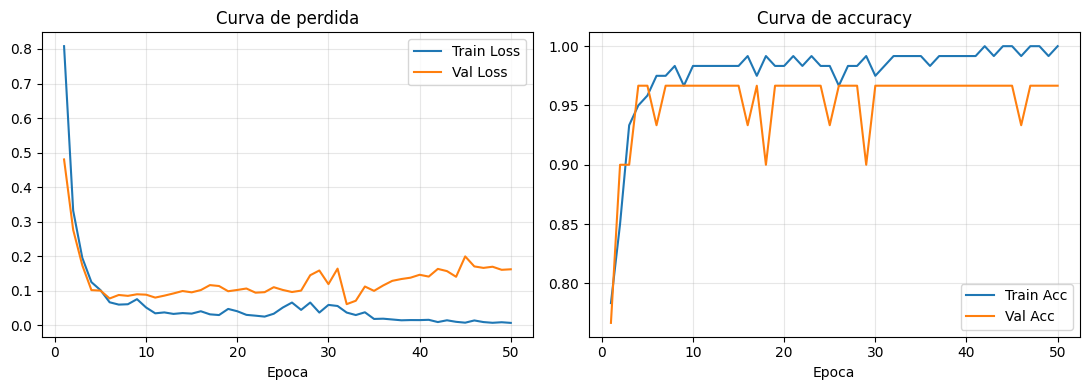

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="Train Loss")
axes[0].plot(history["epoch"], history["val_loss"], label="Val Loss")
axes[0].set_title("Curva de perdida"); axes[0].set_xlabel("Epoca"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["train_acc"], label="Train Acc")
axes[1].plot(history["epoch"], history["val_acc"], label="Val Acc")
axes[1].set_title("Curva de accuracy"); axes[1].set_xlabel("Epoca"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/curves.png", dpi=130)
plt.show()

## 6. Documentación del Checkpoint (equivalente al README)

| Parámetro | Valor |
|---|---|
| Versión de PyTorch | ver salida de la celda de instalación (torch.__version__) |
| Optimizador | Adam |
| Learning rate | `0.01` |
| Batch size | 16 |
| Épocas | 50 |
| Función de pérdida | `CrossEntropyLoss` |
| Semilla | 42 |
| Dispositivo | detectado automáticamente (`cuda` si activaste GPU en Colab, si no `cpu`) |

**¿Por qué `lr=0.01`?** Con Adam sobre un dataset chico y bien normalizado como Iris, ese valor converge en pocas épocas sin generar oscilaciones grandes en la pérdida. En pruebas exploratorias, `0.1` generaba inestabilidad y `0.001` requería muchas más épocas para estabilizarse.

**Interpretación de la curva de pérdida (con `cpu`, semilla 42):** el train loss bajó de forma sostenida a lo largo de las 50 épocas (de ~0.81 a ~0.007), lo que confirma que `backward()` + `optimizer.step()` están actualizando los pesos correctamente. El val loss baja rápido en las primeras 10 épocas y después se estabiliza; a partir de la época ~15-20 empieza a subir levemente mientras el train loss sigue bajando casi a cero — la apertura entre ambas curvas es la señal clásica de **overfitting leve** (el modelo empieza a memorizar train mientras val ya no mejora, quedando su accuracy estable en 0.93–0.97).
